# Dose Response Study

Simulating dose response experiments.

We begin by importing required packages.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.optimize as opt
import statistics
from scipy import stats
import os
import re
import ptitprince as pt #rain plots
from datetime import date

import disturbances as dt
import normalization as nrm
import dose_response as dr
import utilities as util

## Data Generation

Here you can specify the particulars of the experiment.

In [2]:
## Simulation parameters
## Ensure the appropriate PLAID layouts exist under compounds_PLAID_layouts 

concentrations = 8 #Possible to use 4, 6, 8
replicates = 3

compounds = int((14*22-20)/(concentrations*replicates))

if concentrations == 4:
    dilution = 15
elif concentrations == 6:
    dilution = 18
elif concentrations == 8:
    dilution = 8
elif concentrations == 12:
    dilution = 4
else:
    print("Please specify the dilution factor")


expected_noise = 0.01
error_l = 15 #High
#error_nl = 2 #High
#error_nl = 0.5 #High
#error_nl = 0.25 #High
#error_nl = 0.125 #High
error_nl = 0.085 #Low or medium?
#error_nl = 0.2 #right half
#error_nl = 0.4 #right half
my_min_dist = 0

In [3]:
slopes = [0.5,1,1.5,2]

#error_types = [{'type':"left", 'error_function':dt.add_exponential_errors_to_left_columns,'error_correction':nrm.normalize_plate_column_effect,'error':error_nl}]
#error_types = [{'type':"diagonal", 'error_function':dt.add_diagonal_errors,'error_correction':nrm.normalize_plate_nearest_control,'error':error_nl}]
#error_types = [{'type':"right-half", 'error_function':dt.add_errors_to_right_columns_half,'error_correction':nrm.normalize_plate_nearest_control,'error':error_nl}]
error_types = [{'type':"bowl-nl", 'error_function':dt.add_bowlshaped_errors_nl,'error_correction':nrm.normalize_plate_nearest_control,'error':error_nl}]
               #{'type':"bowl", 'error_function':dt.add_bowlshaped_errors,'error_correction':nrm.normalize_plate_nearest_control,'error':error_l}]
               #{'type':"left-nl", 'error_function':dt.add_errors_to_left_columns,'error_correction':nrm.normalize_plate_column_effect,'error':error_nl},
               #{'type':"left", 'error_function':dt.add_linear_errors_to_left_columns,'error_correction':nrm.normalize_plate_column_effect,'error':error_l},
               #{'type':"right", 'error_function':dt.add_linear_errors_to_right_columns,'error_correction':nrm.normalize_plate_column_effect,'error':error_l},
               #{'type':"top-nl", 'error_function':dt.add_errors_to_upper_rows,'error_correction':nrm.normalize_plate_row_effect,'error':error_nl},
               #{'type':"top", 'error_function':dt.add_linear_errors_to_upper_rows,'error_correction':nrm.normalize_plate_row_effect,'error':error_l},
               #{'type':"bottom", 'error_function':dt.add_linear_errors_to_lower_rows,'error_correction':nrm.normalize_plate_row_effect,'error':error_l},
               #{'type':"left-exp", 'error_function':dt.add_exponential_errors_to_left_columns,'error_correction':nrm.normalize_plate_column_effect,'error':error_nl},
               #{'type':"top-exp", 'error_function':dt.add_exponential_errors_to_upper_rows,'error_correction':nrm.normalize_plate_row_effect,'error':error_nl}]
#{'type':,error_function':,'error_correction':}


plate_types_location = [{'type':'PLAID','dir':'compounds_PLAID_layouts/','regex':'plate_layout_(.*)'+str(compounds)+'-'+str(concentrations)+'-'+str(replicates)+'_(0*)(.+?).npy','error_correction':nrm.normalize_plate_lowess_2d},
                        {'type':'RANDOM','dir':'compounds_manual_layouts/','regex':'plate_layout_rand_(.+?).npy','error_correction':nrm.normalize_plate_lowess_2d},
                        {'type':'BORDER','dir':'compounds_manual_layouts/','regex':'plate_layout_border_(.+?).npy','error_correction':nrm.normalize_plate_linear}]

## Results
absolute_ic50_data = np.empty((0,7))
relative_ic50_data = np.empty((0,7))
residuals = np.empty((0,7)) #Columns: "layout", "method", "Error", "E", "R_lost", "residuals", "true_residuals"

today = (date.today()).strftime("%Y%m%d")+"-debug-reg"

absolute_ic50_data_f=open('absolute_ic50_data-'+str(compounds)+'-'+str(concentrations)+'-dil'+str(dilution)+'-'+str(replicates)+'-'+str(error_nl)+'-'+today+'.csv','a')
relative_ic50_data_f=open('relative_ic50_data-'+str(compounds)+'-'+str(concentrations)+'-dil'+str(dilution)+'-'+str(replicates)+'-'+str(error_nl)+'-'+today+'.csv','a')
residuals_f=open('residuals-'+str(compounds)+'-'+str(concentrations)+'-dil'+str(dilution)+'-'+str(replicates)+'-'+str(error_nl)+'-'+today+'.csv','a')

Now we place them on a plate, add a small random noise, apply plate effects error and correct them.

Testing e: 50
            b  c    d          e  startDose  nDose  dilution   abs IC50
compound                                                               
0         0.5  0  100  53.935017      10000      8         8  53.935017
1         1.0  0  100  51.975136      10000      8         8  51.975136
2         1.5  0  100  54.490162      10000      8         8  54.490162
3         0.5  0  100  52.406185      10000      8         8  52.406185
4         1.0  0  100  52.756225      10000      8         8  52.756225
5         1.5  0  100  50.436030      10000      8         8  50.436030
6         0.5  0  100  54.456066      10000      8         8  54.456066
7         1.0  0  100  54.700186      10000      8         8  54.700186
8         1.5  0  100  53.954827      10000      8         8  53.954827
9         0.5  0  100  50.527424      10000      8         8  50.527424
10        1.0  0  100  51.569647      10000      8         8  51.569647
11        1.5  0  100  50.683980      10000      8

/home/jovyan/validation/normalization.py:278: RuntimeWarning: divide by zero encountered in log10
  plate_array = np.log10(plate_array_in)



Plotting curve for compound 0
The score of this fit is: 0.9422550978587146

The original IC50 is: compound
0    53.935017
Name: e, dtype: float64

The estimated IC50 is: 31.81029449983394

The absolute log error is: compound
0    0.229303
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         0  10000.000000  1.00000   6.841596    8.165360
1         0   1250.000000  1.90309  17.199419   15.697615
2         0    156.250000  2.80618  37.008815   35.820587
3         0     19.531250  3.70927  62.430986   52.148204
4         0      2.441406  4.61236  82.456724   90.528661
5         0      0.305176  5.51545  93.004128  102.691916
6         0      0.038147  6.41854  97.409428   91.948107
7         0      0.004768  7.32163  99.068495   96.799531
0         0  10000.000000  1.00000   6.841596    6.995897
1         0   1250.000000  1.90309  17.199419   16.508320
2         0    156.250000  2.80618  37.008815   26.878423
3         0     19.531250  3.70927  62.

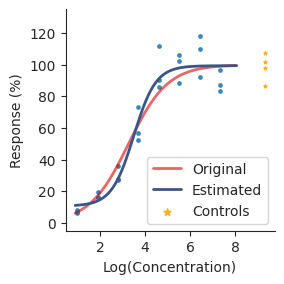


Plotting curve for compound 1
The score of this fit is: 0.952355503469365

The original IC50 is: compound
1    51.975136
Name: e, dtype: float64

The estimated IC50 is: 54.10383480312131

The absolute log error is: compound
1    0.017432
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         1  10000.000000  1.00000   0.517064    0.387406
1         1   1250.000000  1.90309   3.992022    3.774344
2         1    156.250000  2.80618  24.961029   21.329446
3         1     19.531250  3.70927  72.686006   69.338399
4         1      2.441406  4.61236  95.513485   95.728861
5         1      0.305176  5.51545  99.416270  104.095592
6         1      0.038147  6.41854  99.926659   91.595023
7         1      0.004768  7.32163  99.990827  110.357991
0         1  10000.000000  1.00000   0.517064    0.433805
1         1   1250.000000  1.90309   3.992022    3.158387
2         1    156.250000  2.80618  24.961029   26.139488
3         1     19.531250  3.70927  72.6

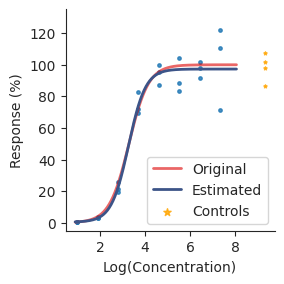


Plotting curve for compound 2
The score of this fit is: 0.9220494153990546

The original IC50 is: compound
2    54.490162
Name: e, dtype: float64

The estimated IC50 is: 50.23549863273551

The absolute log error is: compound
2    0.035307
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         2  10000.000000  1.00000   0.040207    0.044236
1         2   1250.000000  1.90309   0.901939    0.874831
2         2    156.250000  2.80618  17.077343   15.802897
3         2     19.531250  3.70927  82.332027   69.428366
4         2      2.441406  4.61236  99.060529  106.483248
5         2      0.305176  5.51545  99.958105   95.943160
6         2      0.038147  6.41854  99.998148   68.723640
7         2      0.004768  7.32163  99.999918   90.114313
0         2  10000.000000  1.00000   0.040207    0.047857
1         2   1250.000000  1.90309   0.901939    1.131769
2         2    156.250000  2.80618  17.077343   13.641707
3         2     19.531250  3.70927  82.

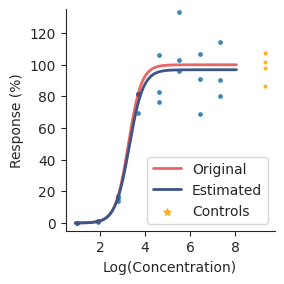


Plotting curve for compound 3
The score of this fit is: 0.9082880186213899

The original IC50 is: compound
3    52.406185
Name: e, dtype: float64

The estimated IC50 is: 99.12597531476509

The absolute log error is: compound
3    0.276805
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         3  10000.000000  1.00000   6.750527    5.389500
1         3   1250.000000  1.90309  16.995629   14.408305
2         3    156.250000  2.80618  36.674269   34.251165
3         3     19.531250  3.70927  62.093164   56.230184
4         3      2.441406  4.61236  82.247771  102.553125
5         3      0.305176  5.51545  92.910000   77.032290
6         3      0.038147  6.41854  97.372898  117.896101
7         3      0.004768  7.32163  99.055133  107.399933
0         3  10000.000000  1.00000   6.750527    5.281149
1         3   1250.000000  1.90309  16.995629   15.082176
2         3    156.250000  2.80618  36.674269   39.055455
3         3     19.531250  3.70927  62.

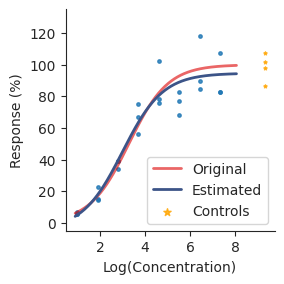


Plotting curve for compound 4
The score of this fit is: 0.9577196874572043

The original IC50 is: compound
4    52.756225
Name: e, dtype: float64

The estimated IC50 is: 40.78133930083735

The absolute log error is: compound
4    0.111812
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         4  10000.000000  1.00000   0.524794    0.608441
1         4   1250.000000  1.90309   4.049585    3.410737
2         4    156.250000  2.80618  25.241461   27.814264
3         4     19.531250  3.70927  72.981142   51.805477
4         4      2.441406  4.61236  95.576973  115.010419
5         4      0.305176  5.51545  99.424863   88.771050
6         4      0.038147  6.41854  99.927744  108.363614
7         4      0.004768  7.32163  99.990962  103.218005
0         4  10000.000000  1.00000   0.524794    0.428249
1         4   1250.000000  1.90309   4.049585    3.764961
2         4    156.250000  2.80618  25.241461   22.415820
3         4     19.531250  3.70927  72.

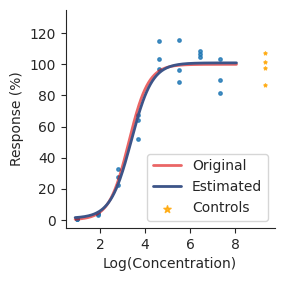


Plotting curve for compound 5
The score of this fit is: 0.9573054076430775

The original IC50 is: compound
5    50.43603
Name: e, dtype: float64

The estimated IC50 is: 46.49974294557571

The absolute log error is: compound
5    0.03529
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         5  10000.000000  1.00000   0.035806    0.031027
1         5   1250.000000  1.90309   0.803971    0.710133
2         5    156.250000  2.80618  15.497175   17.396103
3         5     19.531250  3.70927  80.581378   71.152783
4         5      2.441406  4.61236  98.946225   66.262944
5         5      0.305176  5.51545  99.952955   99.749285
6         5      0.038147  6.41854  99.997920  111.410873
7         5      0.004768  7.32163  99.999908   85.020586
0         5  10000.000000  1.00000   0.035806    0.032424
1         5   1250.000000  1.90309   0.803971    0.734306
2         5    156.250000  2.80618  15.497175   12.442595
3         5     19.531250  3.70927  80.58

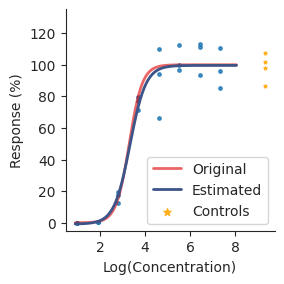


Plotting curve for compound 6
The score of this fit is: 0.8994206750873484

The original IC50 is: compound
6    54.456066
Name: e, dtype: float64

The estimated IC50 is: 29.758520330693134

The absolute log error is: compound
6    0.262435
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         6  10000.000000  1.00000   6.872298    5.443968
1         6   1250.000000  1.90309  17.267987   19.334366
2         6    156.250000  2.80618  37.120950   30.416598
3         6     19.531250  3.70927  62.543668   52.781856
4         6      2.441406  4.61236  82.526154   83.741729
5         6      0.305176  5.51545  93.035341  119.245823
6         6      0.038147  6.41854  97.421531  113.317579
7         6      0.004768  7.32163  99.072921   71.848027
0         6  10000.000000  1.00000   6.872298    7.967558
1         6   1250.000000  1.90309  17.267987   15.827619
2         6    156.250000  2.80618  37.120950   39.683728
3         6     19.531250  3.70927  62

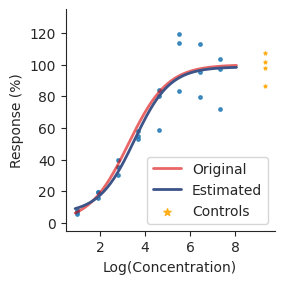


Plotting curve for compound 7
The score of this fit is: 0.9668699949709846

The original IC50 is: compound
7    54.700186
Name: e, dtype: float64

The estimated IC50 is: 52.8357350620375

The absolute log error is: compound
7    0.015061
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         7  10000.000000  1.00000   0.544026    0.461131
1         7   1250.000000  1.90309   4.192548    5.129023
2         7    156.250000  2.80618  25.930381   25.905893
3         7     19.531250  3.70927  73.688708   66.244417
4         7      2.441406  4.61236  95.727444  103.079630
5         7      0.305176  5.51545  99.445189   81.269234
6         7      0.038147  6.41854  99.930310   96.080861
7         7      0.004768  7.32163  99.991283   96.424810
0         7  10000.000000  1.00000   0.544026    0.491667
1         7   1250.000000  1.90309   4.192548    4.104674
2         7    156.250000  2.80618  25.930381   21.099122
3         7     19.531250  3.70927  73.6

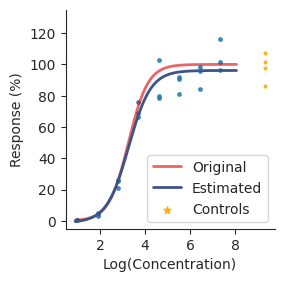


Plotting curve for compound 8
The score of this fit is: 0.9405873696477695

The original IC50 is: compound
8    53.954827
Name: e, dtype: float64

The estimated IC50 is: 76.70780728550139

The absolute log error is: compound
8    0.152809
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         8  10000.000000  1.00000   0.039616    0.039069
1         8   1250.000000  1.90309   0.888798    0.954153
2         8    156.250000  2.80618  16.868648   17.161605
3         8     19.531250  3.70927  82.115570   71.499984
4         8      2.441406  4.61236  99.046646   90.873095
5         8      0.305176  5.51545  99.957480   85.520491
6         8      0.038147  6.41854  99.998120  117.018140
7         8      0.004768  7.32163  99.999917   77.912865
0         8  10000.000000  1.00000   0.039616    0.033257
1         8   1250.000000  1.90309   0.888798    0.775411
2         8    156.250000  2.80618  16.868648   19.854626
3         8     19.531250  3.70927  82.

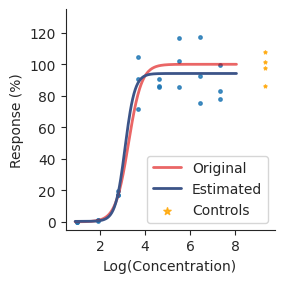


Plotting curve for compound 9
The score of this fit is: 0.906024694708179

The original IC50 is: compound
9    50.527424
Name: e, dtype: float64

The estimated IC50 is: 45.96772001354855

The absolute log error is: compound
9    0.041074
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         9  10000.000000  1.00000   6.636523    7.327278
1         9   1250.000000  1.90309  16.739664   13.989718
2         9    156.250000  2.80618  36.251370   32.614570
3         9     19.531250  3.70927  61.662566   64.649662
4         9      2.441406  4.61236  81.979674   95.603517
5         9      0.305176  5.51545  92.788808   80.807226
6         9      0.038147  6.41854  97.325797   76.745700
7         9      0.004768  7.32163  99.037894  104.034898
0         9  10000.000000  1.00000   6.636523    7.069205
1         9   1250.000000  1.90309  16.739664   13.675834
2         9    156.250000  2.80618  36.251370   32.724178
3         9     19.531250  3.70927  61.6

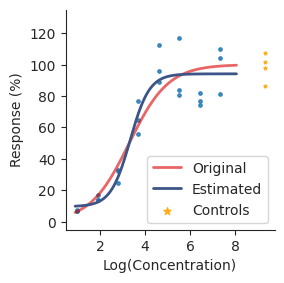


Plotting curve for compound 10
The score of this fit is: 0.9562759266619794

The original IC50 is: compound
10    51.569647
Name: e, dtype: float64

The estimated IC50 is: 62.79205024594215

The absolute log error is: compound
10    0.085511
Name: e, dtype: float64

   compound          dose  logDose   response     results
0        10  10000.000000  1.00000   0.513051    0.456156
1        10   1250.000000  1.90309   3.962112    4.470001
2        10    156.250000  2.80618  24.814616   25.422472
3        10     19.531250  3.70927  72.530234   66.418227
4        10      2.441406  4.61236  95.479803   88.219478
5        10      0.305176  5.51545  99.411707   77.809353
6        10      0.038147  6.41854  99.926083   93.021079
7        10      0.004768  7.32163  99.990754   86.609869
0        10  10000.000000  1.00000   0.513051    0.527773
1        10   1250.000000  1.90309   3.962112    4.212952
2        10    156.250000  2.80618  24.814616   29.433532
3        10     19.531250  3.70927  

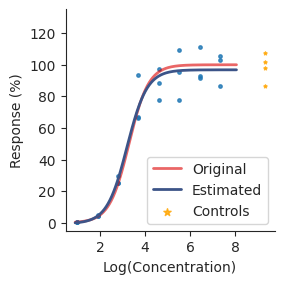


Plotting curve for compound 11
The score of this fit is: 0.9589487684760207

The original IC50 is: compound
11    50.68398
Name: e, dtype: float64

The estimated IC50 is: 50.34470574299364

The absolute log error is: compound
11    0.002917
Name: e, dtype: float64

   compound          dose  logDose   response     results
0        11  10000.000000  1.00000   0.036070    0.034198
1        11   1250.000000  1.90309   0.809859    0.956511
2        11    156.250000  2.80618  15.593752   15.229974
3        11     19.531250  3.70927  80.696226   69.002962
4        11      2.441406  4.61236  98.953867  114.319254
5        11      0.305176  5.51545  99.953300   87.719339
6        11      0.038147  6.41854  99.997935  119.942050
7        11      0.004768  7.32163  99.999909   97.027282
0        11  10000.000000  1.00000   0.036070    0.046841
1        11   1250.000000  1.90309   0.809859    0.814899
2        11    156.250000  2.80618  15.593752   13.232004
3        11     19.531250  3.70927  8

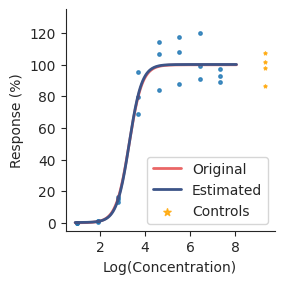

RESULT!!
0.07046237507657556
0.10547977245361116


compound
0     0.942255
1     0.952356
2     0.922049
3     0.908288
4     0.957720
5     0.957305
6     0.899421
7     0.966870
8     0.940587
9     0.906025
10    0.956276
11    0.958949
Name: r2_score, dtype: float64




Testing plates: RANDOM
RANDOM
plate_layout_rand_02.npy


/home/jovyan/validation/normalization.py:278: RuntimeWarning: divide by zero encountered in log10
  plate_array = np.log10(plate_array_in)



Plotting curve for compound 0
The score of this fit is: 0.9279937016350416

The original IC50 is: compound
0    53.935017
Name: e, dtype: float64

The estimated IC50 is: 29.208821691556278

The absolute log error is: compound
0    0.266357
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         0  10000.000000  1.00000   6.841596    7.524800
1         0   1250.000000  1.90309  17.199419   15.224135
2         0    156.250000  2.80618  37.008815   32.661807
3         0     19.531250  3.70927  62.430986   57.622354
4         0      2.441406  4.61236  82.456724  100.717835
5         0      0.305176  5.51545  93.004128   84.868361
6         0      0.038147  6.41854  97.409428  120.773366
7         0      0.004768  7.32163  99.068495  102.660472
0         0  10000.000000  1.00000   6.841596    7.446526
1         0   1250.000000  1.90309  17.199419   16.039907
2         0    156.250000  2.80618  37.008815   34.560188
3         0     19.531250  3.70927  62

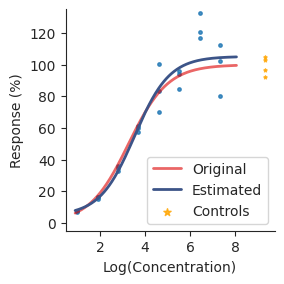


Plotting curve for compound 1
The score of this fit is: 0.9119696490429461

The original IC50 is: compound
1    51.975136
Name: e, dtype: float64

The estimated IC50 is: 60.3211670337721

The absolute log error is: compound
1    0.064674
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         1  10000.000000  1.00000   0.517064    0.468143
1         1   1250.000000  1.90309   3.992022    4.540067
2         1    156.250000  2.80618  24.961029   29.575594
3         1     19.531250  3.70927  72.686006  100.460113
4         1      2.441406  4.61236  95.513485   87.022070
5         1      0.305176  5.51545  99.416270   74.944572
6         1      0.038147  6.41854  99.926659  104.653821
7         1      0.004768  7.32163  99.990827  107.036254
0         1  10000.000000  1.00000   0.517064    0.722960
1         1   1250.000000  1.90309   3.992022    3.261989
2         1    156.250000  2.80618  24.961029   24.274800
3         1     19.531250  3.70927  72.6

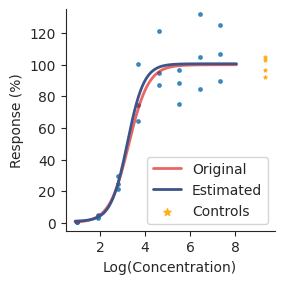


Plotting curve for compound 2
The score of this fit is: 0.9367415759564028

The original IC50 is: compound
2    54.490162
Name: e, dtype: float64

The estimated IC50 is: 82.96507281375825

The absolute log error is: compound
2    0.182577
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         2  10000.000000  1.00000   0.040207    0.032395
1         2   1250.000000  1.90309   0.901939    1.132853
2         2    156.250000  2.80618  17.077343   14.204627
3         2     19.531250  3.70927  82.332027  100.479753
4         2      2.441406  4.61236  99.060529   84.144170
5         2      0.305176  5.51545  99.958105   87.048429
6         2      0.038147  6.41854  99.998148   71.706419
7         2      0.004768  7.32163  99.999918   78.415321
0         2  10000.000000  1.00000   0.040207    0.040342
1         2   1250.000000  1.90309   0.901939    0.878589
2         2    156.250000  2.80618  17.077343   14.232088
3         2     19.531250  3.70927  82.

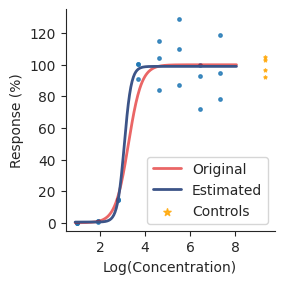


Plotting curve for compound 3
The score of this fit is: 0.9257048025249398

The original IC50 is: compound
3    52.406185
Name: e, dtype: float64

The estimated IC50 is: 53.008035037774356

The absolute log error is: compound
3    0.004959
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         3  10000.000000  1.00000   6.750527    7.057028
1         3   1250.000000  1.90309  16.995629   17.398494
2         3    156.250000  2.80618  36.674269   34.828393
3         3     19.531250  3.70927  62.093164   73.800800
4         3      2.441406  4.61236  82.247771  107.768268
5         3      0.305176  5.51545  92.910000  121.651319
6         3      0.038147  6.41854  97.372898  112.326026
7         3      0.004768  7.32163  99.055133  100.642758
0         3  10000.000000  1.00000   6.750527    7.646884
1         3   1250.000000  1.90309  16.995629   14.520670
2         3    156.250000  2.80618  36.674269   38.280529
3         3     19.531250  3.70927  62

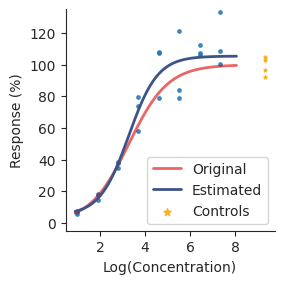


Plotting curve for compound 4
The score of this fit is: 0.945105993376394

The original IC50 is: compound
4    52.756225
Name: e, dtype: float64

The estimated IC50 is: 67.13968036877134

The absolute log error is: compound
4    0.104706
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         4  10000.000000  1.00000   0.524794    0.590650
1         4   1250.000000  1.90309   4.049585    3.093598
2         4    156.250000  2.80618  25.241461   27.880445
3         4     19.531250  3.70927  72.981142   96.246439
4         4      2.441406  4.61236  95.576973  111.839269
5         4      0.305176  5.51545  99.424863  105.866523
6         4      0.038147  6.41854  99.927744   94.097975
7         4      0.004768  7.32163  99.990962   89.753006
0         4  10000.000000  1.00000   0.524794    0.471716
1         4   1250.000000  1.90309   4.049585    3.580918
2         4    156.250000  2.80618  25.241461   24.849323
3         4     19.531250  3.70927  72.9

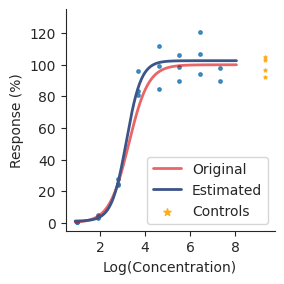


Plotting curve for compound 5
The score of this fit is: 0.9356246997282084

The original IC50 is: compound
5    50.43603
Name: e, dtype: float64

The estimated IC50 is: 68.30807593932535

The absolute log error is: compound
5    0.131731
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         5  10000.000000  1.00000   0.035806    0.038881
1         5   1250.000000  1.90309   0.803971    0.771627
2         5    156.250000  2.80618  15.497175   21.251130
3         5     19.531250  3.70927  80.581378  102.379931
4         5      2.441406  4.61236  98.946225  108.242367
5         5      0.305176  5.51545  99.952955  134.030142
6         5      0.038147  6.41854  99.997920   83.048786
7         5      0.004768  7.32163  99.999908  108.807420
0         5  10000.000000  1.00000   0.035806    0.044429
1         5   1250.000000  1.90309   0.803971    0.681951
2         5    156.250000  2.80618  15.497175   18.925815
3         5     19.531250  3.70927  80.5

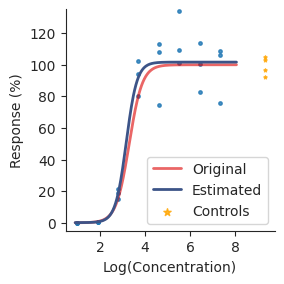


Plotting curve for compound 6
The score of this fit is: 0.896386833970482

The original IC50 is: compound
6    54.456066
Name: e, dtype: float64

The estimated IC50 is: 59.28301047584207

The absolute log error is: compound
6    0.036884
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         6  10000.000000  1.00000   6.872298    6.334449
1         6   1250.000000  1.90309  17.267987   17.127898
2         6    156.250000  2.80618  37.120950   36.277801
3         6     19.531250  3.70927  62.543668   59.145893
4         6      2.441406  4.61236  82.526154   91.339291
5         6      0.305176  5.51545  93.035341   66.446695
6         6      0.038147  6.41854  97.421531  134.579094
7         6      0.004768  7.32163  99.072921  105.869891
0         6  10000.000000  1.00000   6.872298   10.012378
1         6   1250.000000  1.90309  17.267987   22.630649
2         6    156.250000  2.80618  37.120950   44.911622
3         6     19.531250  3.70927  62.5

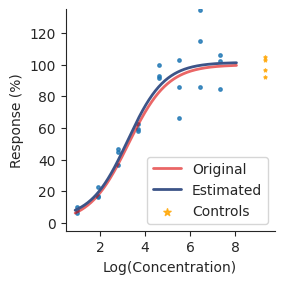


Plotting curve for compound 7
The score of this fit is: 0.9489804716799402

The original IC50 is: compound
7    54.700186
Name: e, dtype: float64

The estimated IC50 is: 68.67937693815375

The absolute log error is: compound
7    0.098838
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         7  10000.000000  1.00000   0.544026    0.572134
1         7   1250.000000  1.90309   4.192548    4.493481
2         7    156.250000  2.80618  25.930381   23.625484
3         7     19.531250  3.70927  73.688708   79.138623
4         7      2.441406  4.61236  95.727444  111.588886
5         7      0.305176  5.51545  99.445189  127.147923
6         7      0.038147  6.41854  99.930310  100.805570
7         7      0.004768  7.32163  99.991283  107.101340
0         7  10000.000000  1.00000   0.544026    0.685964
1         7   1250.000000  1.90309   4.192548    4.569366
2         7    156.250000  2.80618  25.930381   21.638063
3         7     19.531250  3.70927  73.

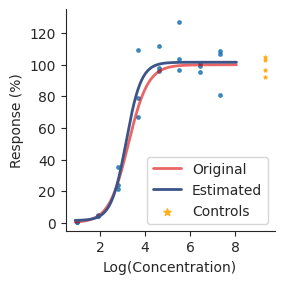


Plotting curve for compound 8
The score of this fit is: 0.9712991665666847

The original IC50 is: compound
8    53.954827
Name: e, dtype: float64

The estimated IC50 is: 45.16381036939578

The absolute log error is: compound
8    0.07724
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         8  10000.000000  1.00000   0.039616    0.037823
1         8   1250.000000  1.90309   0.888798    0.791187
2         8    156.250000  2.80618  16.868648   14.169064
3         8     19.531250  3.70927  82.115570   87.506740
4         8      2.441406  4.61236  99.046646  112.850454
5         8      0.305176  5.51545  99.957480  115.616278
6         8      0.038147  6.41854  99.998120   96.752476
7         8      0.004768  7.32163  99.999917  102.653603
0         8  10000.000000  1.00000   0.039616    0.042909
1         8   1250.000000  1.90309   0.888798    0.822074
2         8    156.250000  2.80618  16.868648   17.646512
3         8     19.531250  3.70927  82.1

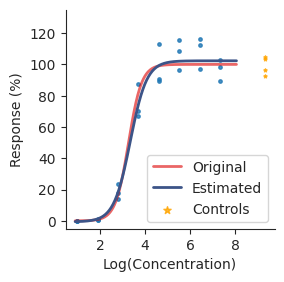


Plotting curve for compound 9
The score of this fit is: 0.897300492117429

The original IC50 is: compound
9    50.527424
Name: e, dtype: float64

The estimated IC50 is: 16.807029178610826

The absolute log error is: compound
9    0.478036
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         9  10000.000000  1.00000   6.636523    6.862771
1         9   1250.000000  1.90309  16.739664   21.643308
2         9    156.250000  2.80618  36.251370   31.253364
3         9     19.531250  3.70927  61.662566   52.864648
4         9      2.441406  4.61236  81.979674   68.569999
5         9      0.305176  5.51545  92.788808   80.817141
6         9      0.038147  6.41854  97.325797  131.241201
7         9      0.004768  7.32163  99.037894   93.487814
0         9  10000.000000  1.00000   6.636523    8.628223
1         9   1250.000000  1.90309  16.739664   19.987575
2         9    156.250000  2.80618  36.251370   33.059889
3         9     19.531250  3.70927  61.

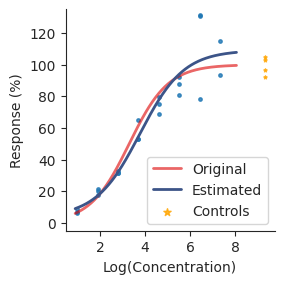


Plotting curve for compound 10
The score of this fit is: 0.9618301917158835

The original IC50 is: compound
10    51.569647
Name: e, dtype: float64

The estimated IC50 is: 69.70178961949082

The absolute log error is: compound
10    0.13085
Name: e, dtype: float64

   compound          dose  logDose   response     results
0        10  10000.000000  1.00000   0.513051    0.459395
1        10   1250.000000  1.90309   3.962112    3.750156
2        10    156.250000  2.80618  24.814616   22.806259
3        10     19.531250  3.70927  72.530234   64.683597
4        10      2.441406  4.61236  95.479803   87.610378
5        10      0.305176  5.51545  99.411707   78.170339
6        10      0.038147  6.41854  99.926083   82.738465
7        10      0.004768  7.32163  99.990754   85.798036
0        10  10000.000000  1.00000   0.513051    0.537327
1        10   1250.000000  1.90309   3.962112    3.956366
2        10    156.250000  2.80618  24.814616   27.714965
3        10     19.531250  3.70927  7

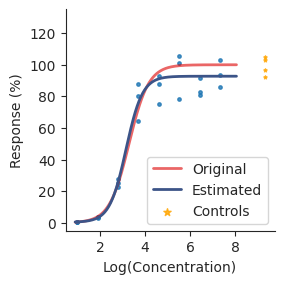


Plotting curve for compound 11
The score of this fit is: 0.9223731429914767

The original IC50 is: compound
11    50.68398
Name: e, dtype: float64

The estimated IC50 is: 46.399740371705725

The absolute log error is: compound
11    0.038355
Name: e, dtype: float64

   compound          dose  logDose   response     results
0        11  10000.000000  1.00000   0.036070    0.056698
1        11   1250.000000  1.90309   0.809859    0.975369
2        11    156.250000  2.80618  15.593752   14.541241
3        11     19.531250  3.70927  80.696226   87.650013
4        11      2.441406  4.61236  98.953867   70.421808
5        11      0.305176  5.51545  99.953300   98.462534
6        11      0.038147  6.41854  99.997935   97.395018
7        11      0.004768  7.32163  99.999909  104.973050
0        11  10000.000000  1.00000   0.036070    0.048546
1        11   1250.000000  1.90309   0.809859    0.993328
2        11    156.250000  2.80618  15.593752   13.262588
3        11     19.531250  3.70927  

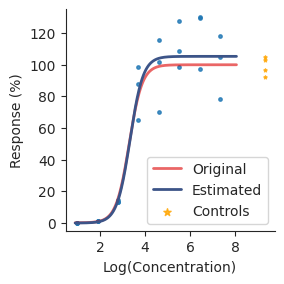

RESULT!!
0.11576832364058347
0.13460053014239293


compound
0     0.927994
1     0.911970
2     0.936742
3     0.925705
4     0.945106
5     0.935625
6     0.896387
7     0.948980
8     0.971299
9     0.897300
10    0.961830
11    0.922373
Name: r2_score, dtype: float64




Testing plates: BORDER
BORDER
plate_layout_border_02.npy

Plotting curve for compound 0
The score of this fit is: 0.884729007718005

The original IC50 is: compound
0    53.935017
Name: e, dtype: float64

The estimated IC50 is: 3612.9043551531763

The absolute log error is: compound
0    1.825986
Name: e, dtype: float64

   compound          dose  logDose   response    results
0         0  10000.000000  1.00000   6.841596   7.692182
1         0   1250.000000  1.90309  17.199419  18.329708
2         0    156.250000  2.80618  37.008815  37.302546
3         0     19.531250  3.70927  62.430986  59.332149
4         0      2.441406  4.61236  82.456724  73.639927
5         0      0.305176  5.51545  93.004128  77.758047
6   

/home/jovyan/validation/normalization.py:330: RuntimeWarning: divide by zero encountered in log10
  plate_array = np.log10(plate_array_in)


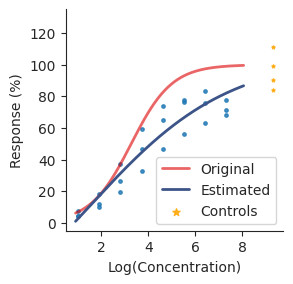


Plotting curve for compound 1
The score of this fit is: 0.8563281802571033

The original IC50 is: compound
1    51.975136
Name: e, dtype: float64

The estimated IC50 is: 37.205549234975386

The absolute log error is: compound
1    0.145188
Name: e, dtype: float64

   compound          dose  logDose   response    results
0         1  10000.000000  1.00000   0.517064   0.346503
1         1   1250.000000  1.90309   3.992022   2.655927
2         1    156.250000  2.80618  24.961029  17.912060
3         1     19.531250  3.70927  72.686006  55.949056
4         1      2.441406  4.61236  95.513485  78.478449
5         1      0.305176  5.51545  99.416270  86.819830
6         1      0.038147  6.41854  99.926659  92.397093
7         1      0.004768  7.32163  99.990827  97.567765
0         1  10000.000000  1.00000   0.517064   0.389544
1         1   1250.000000  1.90309   3.992022   2.833126
2         1    156.250000  2.80618  24.961029  16.735054
3         1     19.531250  3.70927  72.686006  45.

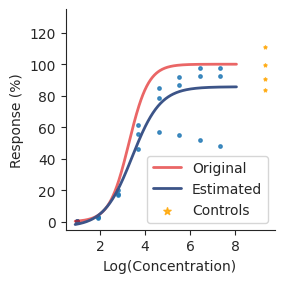


Plotting curve for compound 2
The score of this fit is: 0.7955128121351897

The original IC50 is: compound
2    54.490162
Name: e, dtype: float64

The estimated IC50 is: 55.4523578058181

The absolute log error is: compound
2    0.007602
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         2  10000.000000  1.00000   0.040207    0.041530
1         2   1250.000000  1.90309   0.901939    0.975950
2         2    156.250000  2.80618  17.077343   19.259777
3         2     19.531250  3.70927  82.332027   96.964850
4         2      2.441406  4.61236  99.060529  108.888098
5         2      0.305176  5.51545  99.958105  104.450215
6         2      0.038147  6.41854  99.998148   99.087170
7         2      0.004768  7.32163  99.999918   93.711953
0         2  10000.000000  1.00000   0.040207    0.019810
1         2   1250.000000  1.90309   0.901939    0.400459
2         2    156.250000  2.80618  17.077343    8.152628
3         2     19.531250  3.70927  82.3

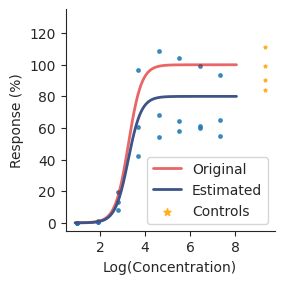


Plotting curve for compound 3
The score of this fit is: 0.9253694369697658

The original IC50 is: compound
3    52.406185
Name: e, dtype: float64

The estimated IC50 is: 6.716713076180982e+31

The absolute log error is: compound
3    30.107774
Name: e, dtype: float64

   compound          dose  logDose   response    results
0         3  10000.000000  1.00000   6.750527   5.966842
1         3   1250.000000  1.90309  16.995629  14.114183
2         3    156.250000  2.80618  36.674269  28.511499
3         3     19.531250  3.70927  62.093164  44.994772
4         3      2.441406  4.61236  82.247771  55.282390
5         3      0.305176  5.51545  92.910000  57.597909
6         3      0.038147  6.41854  97.372898  60.213965
7         3      0.004768  7.32163  99.055133  66.085664
0         3  10000.000000  1.00000   6.750527   4.610293
1         3   1250.000000  1.90309  16.995629  12.178884
2         3    156.250000  2.80618  36.674269  27.508743
3         3     19.531250  3.70927  62.093164 

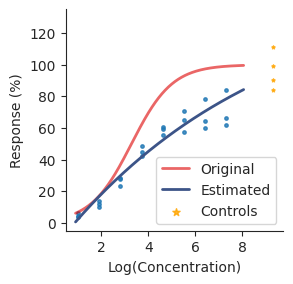


Plotting curve for compound 4
The score of this fit is: 0.7721181094800657

The original IC50 is: compound
4    52.756225
Name: e, dtype: float64

The estimated IC50 is: 44.325862514980514

The absolute log error is: compound
4    0.075617
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         4  10000.000000  1.00000   0.524794    0.378443
1         4   1250.000000  1.90309   4.049585    3.095355
2         4    156.250000  2.80618  25.241461   20.494587
3         4     19.531250  3.70927  72.981142   62.742139
4         4      2.441406  4.61236  95.576973   86.713741
5         4      0.305176  5.51545  99.424863   94.907353
6         4      0.038147  6.41854  99.927744  100.085786
7         4      0.004768  7.32163  99.990962  104.828345
0         4  10000.000000  1.00000   0.524794    0.308641
1         4   1250.000000  1.90309   4.049585    2.224686
2         4    156.250000  2.80618  25.241461   12.915139
3         4     19.531250  3.70927  72

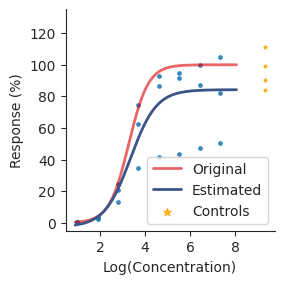


Plotting curve for compound 5
The score of this fit is: 0.9281466816201498

The original IC50 is: compound
5    50.43603
Name: e, dtype: float64

The estimated IC50 is: 44.342667372021694

The absolute log error is: compound
5    0.055919
Name: e, dtype: float64

   compound          dose  logDose   response    results
0         5  10000.000000  1.00000   0.035806   0.041333
1         5   1250.000000  1.90309   0.803971   0.820985
2         5    156.250000  2.80618  15.497175  15.001473
3         5     19.531250  3.70927  80.581378  73.957308
4         5      2.441406  4.61236  98.946225  85.886605
5         5      0.305176  5.51545  99.952955  81.807065
6         5      0.038147  6.41854  99.997920  76.909984
7         5      0.004768  7.32163  99.999908  72.002683
0         5  10000.000000  1.00000   0.035806   0.021042
1         5   1250.000000  1.90309   0.803971   0.463090
2         5    156.250000  2.80618  15.497175   9.408214
3         5     19.531250  3.70927  80.581378  51.6

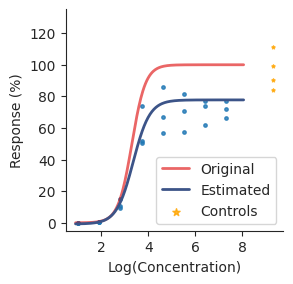


Plotting curve for compound 6
The score of this fit is: 0.8417331279590723

The original IC50 is: compound
6    54.456066
Name: e, dtype: float64

The estimated IC50 is: 263.5487348576344

The absolute log error is: compound
6    0.684815
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         6  10000.000000  1.00000   6.872298    4.612952
1         6   1250.000000  1.90309  17.267987   10.752631
2         6    156.250000  2.80618  37.120950   21.317274
3         6     19.531250  3.70927  62.543668   35.826092
4         6      2.441406  4.61236  82.526154   50.998223
5         6      0.305176  5.51545  93.035341   61.672753
6         6      0.038147  6.41854  97.421531   68.935441
7         6      0.004768  7.32163  99.072921   74.509769
0         6  10000.000000  1.00000   6.872298    5.695710
1         6   1250.000000  1.90309  17.267987   13.600458
2         6    156.250000  2.80618  37.120950   27.722039
3         6     19.531250  3.70927  62.

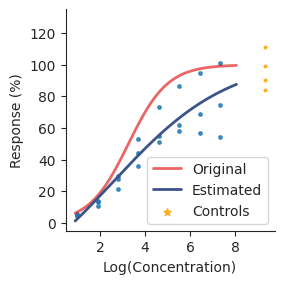


Plotting curve for compound 7
The score of this fit is: 0.864837512249157

The original IC50 is: compound
7    54.700186
Name: e, dtype: float64

The estimated IC50 is: 46.629080431858775

The absolute log error is: compound
7    0.069332
Name: e, dtype: float64

   compound          dose  logDose   response     results
0         7  10000.000000  1.00000   0.544026    0.433531
1         7   1250.000000  1.90309   4.192548    3.524105
2         7    156.250000  2.80618  25.930381   22.926832
3         7     19.531250  3.70927  73.688708   68.365317
4         7      2.441406  4.61236  95.727444   92.959284
5         7      0.305176  5.51545  99.445189  100.859262
6         7      0.038147  6.41854  99.930310   89.203516
7         7      0.004768  7.32163  99.991283   84.640311
0         7  10000.000000  1.00000   0.544026    0.277790
1         7   1250.000000  1.90309   4.192548    1.958923
2         7    156.250000  2.80618  25.930381   12.086822
3         7     19.531250  3.70927  73.

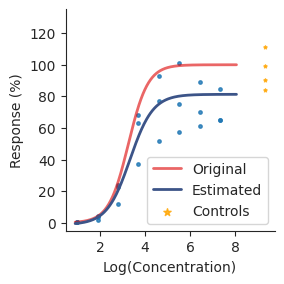


Plotting curve for compound 8
The score of this fit is: 0.9100829352578216

The original IC50 is: compound
8    53.954827
Name: e, dtype: float64

The estimated IC50 is: 42.511865604573565

The absolute log error is: compound
8    0.10352
Name: e, dtype: float64

   compound          dose  logDose   response    results
0         8  10000.000000  1.00000   0.039616   0.035604
1         8   1250.000000  1.90309   0.888798   0.673633
2         8    156.250000  2.80618  16.868648  11.967681
3         8     19.531250  3.70927  82.115570  54.530980
4         8      2.441406  4.61236  99.046646  61.311166
5         8      0.305176  5.51545  99.957480  57.394718
6         8      0.038147  6.41854  99.998120  52.957678
7         8      0.004768  7.32163  99.999917  52.826644
0         8  10000.000000  1.00000   0.039616   0.028238
1         8   1250.000000  1.90309   0.888798   0.642325
2         8    156.250000  2.80618  16.868648  12.736242
3         8     19.531250  3.70927  82.115570  64.8

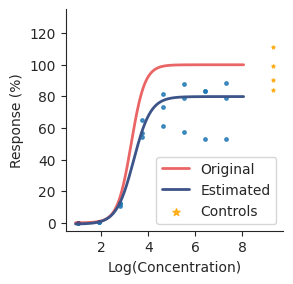


Plotting curve for compound 9
The score of this fit is: 0.7707440901285094

The original IC50 is: compound
9    50.527424
Name: e, dtype: float64

The estimated IC50 is: 2294.248519341248

The absolute log error is: compound
9    1.657113
Name: e, dtype: float64

   compound          dose  logDose   response    results
0         9  10000.000000  1.00000   6.636523   3.784798
1         9   1250.000000  1.90309  16.739664  10.234810
2         9    156.250000  2.80618  36.251370  23.658003
3         9     19.531250  3.70927  61.662566  42.771269
4         9      2.441406  4.61236  81.979674  60.208441
5         9      0.305176  5.51545  92.788808  71.914779
6         9      0.038147  6.41854  97.325797  79.362931
7         9      0.004768  7.32163  99.037894  84.738383
0         9  10000.000000  1.00000   6.636523   4.975520
1         9   1250.000000  1.90309  16.739664  11.832922
2         9    156.250000  2.80618  36.251370  24.078479
3         9     19.531250  3.70927  61.662566  38.3

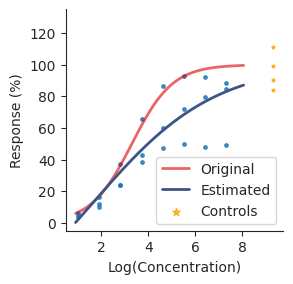


Plotting curve for compound 10
The score of this fit is: 0.922307679664687

The original IC50 is: compound
10    51.569647
Name: e, dtype: float64

The estimated IC50 is: 83.19779377878879

The absolute log error is: compound
10    0.207718
Name: e, dtype: float64

   compound          dose  logDose   response    results
0        10  10000.000000  1.00000   0.513051   0.460203
1        10   1250.000000  1.90309   3.962112   3.706776
2        10    156.250000  2.80618  24.814616  21.384853
3        10     19.531250  3.70927  72.530234  59.417849
4        10      2.441406  4.61236  95.479803  74.171789
5        10      0.305176  5.51545  99.411707  73.038305
6        10      0.038147  6.41854  99.926083  69.222061
7        10      0.004768  7.32163  99.990754  65.092246
0        10  10000.000000  1.00000   0.513051   0.274985
1        10   1250.000000  1.90309   3.962112   2.270757
2        10    156.250000  2.80618  24.814616  15.162735
3        10     19.531250  3.70927  72.530234  47

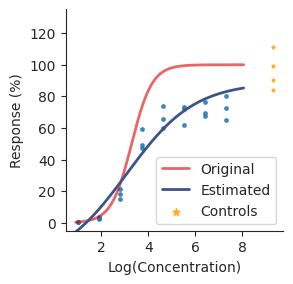


Plotting curve for compound 11
The score of this fit is: 0.8141290365150424

The original IC50 is: compound
11    50.68398
Name: e, dtype: float64

The estimated IC50 is: 41.67338896166924

The absolute log error is: compound
11    0.085012
Name: e, dtype: float64

   compound          dose  logDose   response     results
0        11  10000.000000  1.00000   0.036070    0.024291
1        11   1250.000000  1.90309   0.809859    0.461028
2        11    156.250000  2.80618  15.593752    8.217634
3        11     19.531250  3.70927  80.696226   39.221391
4        11      2.441406  4.61236  98.953867   47.974100
5        11      0.305176  5.51545  99.953300   52.278354
6        11      0.038147  6.41854  99.997935   56.106038
7        11      0.004768  7.32163  99.999909   59.892141
0        11  10000.000000  1.00000   0.036070    0.030722
1        11   1250.000000  1.90309   0.809859    0.712386
2        11    156.250000  2.80618  15.593752   13.766280
3        11     19.531250  3.70927  8

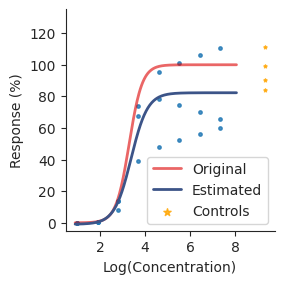

RESULT!!
0.5319816900421416
2.9187995789987116


compound
0     0.884729
1     0.856328
2     0.795513
3     0.925369
4     0.772118
5     0.928147
6     0.841733
7     0.864838
8     0.910083
9     0.770744
10    0.922308
11    0.814129
Name: r2_score, dtype: float64






In [4]:
#for current_e in range(1,100,5):
for current_e in range(50,51,5):
    print("Testing e:",current_e)
    
    # Create new curves/compounds
    params = []
    for i in range(compounds):
        params.append({'compound':i, 'b':slopes[i%3], 'c':0, 'd':100, 'e':(current_e+5*np.random.random()),'startDose':10000, 'nDose':concentrations, 'dilution':dilution})
    
    df_params = pd.DataFrame.from_dict(params)
    df_params.set_index('compound',inplace=True)

    df_params['abs IC50'] = dr.IC50(df_params['b'],df_params['c'],df_params['d'],df_params['e'])
    
    print(df_params)

    compounds_array = df_params.index.to_numpy()

    # The same compounds/concentrations will be used in every plate
    plate_content = dr.generate_plate_content(dose_response_params=params, replicates=replicates)
    
    for plate_type in plate_types_location:
        print("Testing plates:",plate_type['type'])
        layout_dir = plate_type['dir']
        layouts = os.listdir(layout_dir)

        print(plate_type['type'])
        
        layouts = ["plate_layout_20-8-12-3_01.npy","plate_layout_20-24-12-1_09.npy","plate_layout_48-6-1_01.npy","plate_layout_24-6-2_01.npy","plate_layout_20-36-8-1_2.npy","plate_layout_20-18-8-2_2.npy","plate_layout_20-12-8-3_1.npy","plate_layout_rand_02.npy","plate_layout_border_02.npy"]
        
        for layout_file in layouts:
            match = re.search(plate_type['regex'],layout_file)

            if match == None:
                continue

            
            print(layout_file)
            
            layout_file_array = np.full(len(compounds_array),layout_file)
            
            e_array = np.full(len(compounds_array),current_e)

            for et in error_types:
                error_type_array = np.full(len(compounds_array),et['type'])
                error_array = np.full(len(compounds_array),et['error'])    
                for lost_rows in range(1,2): #max 8
                    limits = [#{'from':0, 'to':lost_rows},
                              {'from':16-lost_rows,'to':16}]
                    for limit in limits:
                        r_lost_array = np.full(len(compounds_array),lost_rows)

                        fitTable_new = dr.plate_curves_after_error(layout_dir,layout_file,plate_content,expected_noise,et['error_function'],et['error'],plate_type['error_correction'],my_min_dist,lose_from_row=limit['from'],lose_to_row=limit['to'], df_params=df_params)

                        #print('fitTable_new')
                        #print(fitTable_new)
                        #print('end Table')
                        
                        
                        obtained_absolute_ic50 = dr.IC50(fitTable_new['b'],fitTable_new['c'],fitTable_new['d'],fitTable_new['e'])
                        #plate_mse = np.absolute(np.subtract(fitTable_new['abs IC50'], obtained_absolute_ic50)).mean()

                        #print(obtained_absolute_ic50)
                        
                        res_array = np.concatenate(fitTable_new['residuals'].to_numpy())
                        true_res_array = np.concatenate(fitTable_new['true_residuals'].to_numpy())
                        res_size = len(res_array)
                        
                        plate_residuals = np.vstack([np.full(res_size,layout_file), np.full(res_size,et['type']), np.full(res_size,et['error']), np.full(res_size,current_e), np.full(res_size,lost_rows), res_array, true_res_array])
                        
                        #print(plate_residuals)
                        
                        #print(len(np.concatenate(fitTable_new['residuals'].to_numpy())))
                        
                        #print(plate_residuals.T)
                        residuals = np.vstack([residuals,plate_residuals.T])
                        np.savetxt(residuals_f, plate_residuals.T, delimiter=",",fmt='%s')
                        
                        plate_rel_ic50 = np.absolute(np.subtract(np.log10(df_params['e']), np.log10(fitTable_new['e'])))
                        plate_abs_ic50 = np.absolute(np.subtract(np.log10(df_params['abs IC50']), np.log10(obtained_absolute_ic50)))

                        print("RESULT!!")
                        print(plate_abs_ic50.mean())
                        print(plate_rel_ic50.mean())
                        print("\n")
                        print(fitTable_new['r2_score'])
                        print("\n")
                        
                        rel_results = np.vstack([layout_file_array, compounds_array, plate_rel_ic50.to_numpy(), error_type_array, error_array, e_array, r_lost_array])
                        abs_results = np.vstack([layout_file_array, compounds_array, plate_abs_ic50.to_numpy(), error_type_array, error_array, e_array, r_lost_array])

                        #relative_ic50_data = np.vstack([relative_ic50_data,rel_results.T])
                        #absolute_ic50_data = np.vstack([absolute_ic50_data,abs_results.T])

                        np.savetxt(absolute_ic50_data_f, abs_results.T, delimiter=",",fmt='%s')
                        np.savetxt(relative_ic50_data_f, rel_results.T, delimiter=",",fmt='%s')
                        
                        print("\n")
                        #for _, row in fitTable_new.iterrows():
                         #   temp = dr.IC50(row.b,row.c,row.d,row.e)
                          #  if temp > 100:
                           #     print(row)

                        #print("MSE "+layout_file,":",plate_abs_ic50.mean())
# np.savetxt("my_array.csv", my_array, fmt="%4d", delimiter=",", newline="\n")

In [5]:
absolute_ic50_data_f.close()
relative_ic50_data_f.close()
residuals_f.close()

done_f=open('done-'+str(compounds)+'-'+str(concentrations)+'-dil'+str(dilution)+'-'+str(replicates)+'-'+str(error_nl)+'-'+today+'.csv','a')
done_f.close()

assert false

NameError: name 'false' is not defined

In [ ]:
np.power(10,np.log10([2,4,5]))

In [ ]:
def ll4(x,b,c,d,e): return c + (d-c)/(1+np.exp(b*(np.log(x)-np.log(e))))
def ll42(x,b,c,d,e): return  ( (d-c)/(1+ (x/e)**b  ) ) + c 

def ic50(b,c,d,e): return np.exp(np.log((((d-c)/(50-c)) -1)*(e**b))/b)

dil = 4
start = 10000
#print(ll4(0,0.755487,-33246.46969,99.415264,4.06E+05))
print(dr.ll4(start,2,0,100,40))
print(dr.ll4(start/dil,2,0,100,40))
print(dr.ll4(start/dil**2,2,0,100,40))
print(dr.ll4(start/dil**3,2,0,100,40))
print(dr.ll4(start/dil**4,2,0,100,40))
print(dr.ll4(start/dil**5,2,0,100,40))
print(dr.ll4(start/dil**6,2,0,100,40))
print(dr.ll4(start/dil**7,2,0,100,40))
print(dr.ll4(start/dil**8,2,0,100,40))
print(dr.ll4(start/dil**9,2,0,100,40))
print(dr.ll4(start/dil**10,2,0,100,40))
print(dr.ll4(start/dil**11,2,0,100,40))
print("\n")


print(dr.ll4(start,0.5,0,100,40))
print(dr.ll4(start/dil,0.5,0,100,40))
print(dr.ll4(start/dil**2,0.5,0,100,40))
print(dr.ll4(start/dil**3,0.5,0,100,40))
print(dr.ll4(start/dil**4,0.5,0,100,40))
print(dr.ll4(start/dil**5,0.5,0,100,40))
print(dr.ll4(start/dil**6,0.5,0,100,40))
print(dr.ll4(start/(dil**7),0.5,0,100,40))
print(dr.ll4(start/dil**8,0.5,0,100,40))
print(dr.ll4(start/dil**9,0.5,0,100,40))
print(dr.ll4(start/dil**10,0.5,0,100,40))
print(dr.ll4(start/(dil**11),0.5,0,100,40))
print("\n")


print(ll42(200,2,0,100,10))

print(ll4(10**-6,2,0,100,40))
print(dr.ll4(0.002603082049,2,0,100,40))
print(ll42(0.0000009486450616,2,0,100,40))

#print(ic50(2,0,100,60))


print("check")
small_start = 0.001
print(dr.ll4(small_start,0.5,0,100,40))
print(dr.ll4(small_start*dil,0.5,0,100,40))
print(dr.ll4(small_start*dil**2,0.5,0,100,40))
print(dr.ll4(small_start*dil**3,0.5,0,100,40))
print(dr.ll4(small_start*dil**4,0.5,0,100,40))
print(dr.ll4(small_start*dil**5,0.5,0,100,40))
print(dr.ll4(small_start*dil**6,0.5,0,100,40))
print(dr.ll4(small_start*(dil**7),0.5,0,100,40))
print(dr.ll4(small_start*dil**8,0.5,0,100,40))
print(dr.ll4(small_start*dil**9,0.5,0,100,40))
print(dr.ll4(small_start*dil**10,0.5,0,100,40))
print(dr.ll4(small_start*(dil**11),0.5,0,100,40))

In [ ]:
print(np.random.random())

## Evaluating the absolute IC50

We first look at the mean IC50 obtained for all the compounds using a PLAID layout versus a completly random layout. 

In [ ]:
print(2**3)
## Loading data for a high error=0.125
# 1 replicate
#absolute_ic50_data = np.loadtxt('absolute_ic50_data-48-6-1-20210630.csv', delimiter=',', dtype='str')

# 2 replicate
#absolute_ic50_data = np.loadtxt('absolute_ic50_data-20210621.csv', delimiter=',', dtype='str')

# 3 replicates
#absolute_ic50_data = np.loadtxt('absolute_ic50_data-16-6-3complete-20210716.csv', delimiter=',', dtype='str')


## Loading data for a low error=0.025
# 1 replicate
#absolute_ic50_data = np.loadtxt('absolute_ic50_data-16-6-3-0.025-20210921.csv', delimiter=',', dtype='str')

## Loading data for a high error=0.125 and 4 doses
# 2 replicates
#absolute_ic50_data = np.loadtxt('absolute_ic50_data-36-4-2-8-20211212.csv', delimiter=',', dtype='str')

In [ ]:
results_df = pd.DataFrame(absolute_ic50_data, columns=["layout", "compound_id", "MSE", "error type", "Error", "E", "rows lost"])
results_df.MSE = pd.to_numeric(results_df.MSE, errors='coerce')
#results_df.MSE = pd.to_numeric(results_df.MSE, errors='coerce')

results_df = results_df.sort_values("MSE")

results_df = results_df[np.logical_not(np.isnan(results_df['MSE']))]

#results_df = results_df.loc[(results_df['error type'] != "bowl") & (results_df['error type'] != "left") & (results_df['error type'] != "top")]

print(results_df)

results_df.loc[(results_df['layout'] >= "plate_layout_rand"), 'layout'] = "RANDOM"
results_df.loc[(results_df['layout'] >= "plate_layout_border") & (results_df['layout'] != "RANDOM"), 'layout'] = "BORDER"
results_df.loc[(results_df['layout'] >= "plate_layout") & (results_df['layout'] != "RANDOM") & (results_df['layout'] != "BORDER"), 'layout'] = "TEST"


#print(results_df[results_df['layout']=='PLAID'].describe())

print(results_df[results_df['layout']=='RANDOM'].describe())

print(results_df[results_df['layout']=='BORDER'].describe())

fig, ax = plt.subplots(figsize=(4, 4))

ax.set(ylim=(0,1))


ax = sns.barplot(x="layout", y="MSE", data=results_df[results_df['MSE']!=np.inf], order=["TEST", "RANDOM", "BORDER"])

#ax = sns.barplot(x="layout", y="MSE", data=results_df[results_df['MSE']!=np.inf], order=["PLAID", "RANDOM"])

ax.set(xlabel='', ylabel='')

plt.show()


In [ ]:
fig.savefig("dose-response-absic50-48-4-2-sq-essense.png",bbox_inches='tight')

In [ ]:
## Plot Absolute IC50
results_df = pd.DataFrame(absolute_ic50_data, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])
results_df.MSE = pd.to_numeric(results_df.MSE, errors='coerce')

results_df["rows lost"] = pd.to_numeric(results_df["rows lost"], errors='coerce')
results_df["E"] = pd.to_numeric(results_df["E"], errors='coerce')

results_df = results_df.sort_values("MSE")

results_df = results_df[np.logical_not(np.isnan(results_df['MSE']))]
print(results_df)

results_df.loc[(results_df['layout'] >= "plate_layout_rand"), 'layout'] = "RANDOM"
results_df.loc[(results_df['layout'] >= "plate_layout_border") & (results_df['layout'] != "RANDOM"), 'layout'] = "BORDER"
results_df.loc[(results_df['layout'] >= "plate_layout") & (results_df['layout'] != "RANDOM") & (results_df['layout'] != "BORDER"), 'layout'] = "PLAID"

temp_none = results_df[(results_df['MSE']!=np.inf) & (results_df['rows lost']<2) ]

#print(temp_none[temp_none['layout']=='PLAID'].describe())

#print(temp_none[temp_none['layout']=='RANDOM'].describe())

#print(temp_none[temp_none['layout']=='BORDER'].describe())


#temp_half = results_df[(results_df['MSE']!=np.inf) & (results_df['rows lost']<=1) & (results_df['E']>70) & (results_df['E']<80) ]
temp_half = results_df[(results_df['rows lost']<=1) & (results_df['MSE']!=np.inf) ]
#ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])
#plt.show()

print(temp_half[temp_half['layout']=='PLAID'].describe())

print(temp_half[temp_half['layout']=='RANDOM'].describe())

#print(temp_half[temp_half['layout']=='BORDER'].describe())


fig, ax = plt.subplots(figsize=(6, 15))

ax.set(ylim=(0,0.6))

ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM","BORDER"])
#plt.show()

In [ ]:
fig.savefig("dose-response-absic50-16-6-3.png",bbox_inches='tight')

In [ ]:
import ptitprince as pt

#temp_half.loc[(temp_half['layout']=='PLAID') & (temp_half["MSE"]>0.688),"MSE"] = 0.1

fig, ax = plt.subplots(figsize=(15, 10))

#ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])

#sns.barplot(x = "group", y = "score", data = df, capsize= .1)
pal = sns.color_palette(n_colors=1)

#ax=pt.half_violinplot( x = "MSE", y = "layout", data = temp_half, palette = pal, bw = .2, cut = 0.,
 #                     scale = "area", width = .6, inner = None, orient = ort, order=["PLAID", "RANDOM"])

dx = "MSE"; dy = "layout"; ort = "h"; pal = "Set2"; sigma = 0.01
#f, ax = plt.subplots(figsize=(7, 5))

pt.RainCloud(x = "layout", y = "MSE", data = temp_none, palette = pal, bw = sigma,
                 width_viol = 1.3, ax = ax, orient = ort, order=["PLAID", "RANDOM","BORDER"], jitter = 0.15)

#ax = sns.violinplot(x="MSE", y="layout", data=temp_half, order=["PLAID", "RANDOM"])
#ax = sns.stripplot(x="MSE", y="layout", data=temp_half,morder=["PLAID", "RANDOM"], jitter=0.3)



In [ ]:
#fig.savefig("dose-response-absic50-plaid-rand-36-4-2_0.125_0.25.png")

rand_results_array = results_df.MSE[results_df.layout=="RANDOM"]
plaid_results_array = results_df.MSE[results_df.layout=="PLAID"]
border_results_array = results_df.MSE[results_df.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array))

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array))
print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))

print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))

print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

In [ ]:
rand_results_array = temp_none.MSE[temp_none.layout=="RANDOM"]
plaid_results_array = temp_none.MSE[temp_none.layout=="PLAID"]
border_results_array = temp_none.MSE[temp_none.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array))

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array))
print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))

print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))

print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

In [ ]:
rand_results_array = temp_half.MSE[temp_half.layout=="RANDOM"]
plaid_results_array = temp_half.MSE[temp_half.layout=="PLAID"]
border_results_array = temp_half.MSE[temp_half.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array))

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array))
print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))

print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))

print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

### Plotting results for multiple replicates together

This is how we generate the plots for the paper.

In [ ]:
## Loading data for a high error=0.125
# 1 replicate
absolute_ic50_data_1rep = np.loadtxt('absolute_ic50_data-48-6-1-20210630.csv', delimiter=',', dtype='str')

# 2 replicate
absolute_ic50_data_2rep = np.loadtxt('absolute_ic50_data-20210621.csv', delimiter=',', dtype='str')

# 3 replicates
absolute_ic50_data_3rep = np.loadtxt('absolute_ic50_data-16-6-3complete-20210716.csv', delimiter=',', dtype='str')

In [ ]:
results_df = pd.DataFrame(absolute_ic50_data_1rep, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])

results_df_2rep = pd.DataFrame(absolute_ic50_data_2rep, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])

results_df_3rep = pd.DataFrame(absolute_ic50_data_3rep, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])

results_df.insert(0, 'replicates', 1)
results_df_2rep.insert(0, 'replicates', 2)
results_df_3rep.insert(0, 'replicates', 3)

results_df = results_df.append(results_df_2rep)
results_df = results_df.append(results_df_3rep)

results_df.MSE = pd.to_numeric(results_df.MSE, errors='coerce')

results_df = results_df[np.logical_not(np.isnan(results_df['MSE']))]

results_df.loc[(results_df['layout'] >= "plate_layout_rand"), 'layout'] = "RANDOM"
results_df.loc[(results_df['layout'] >= "plate_layout_border") & (results_df['layout'] != "RANDOM"), 'layout'] = "BORDER"
results_df.loc[(results_df['layout'] >= "plate_layout") & (results_df['layout'] != "RANDOM") & (results_df['layout'] != "BORDER"), 'layout'] = "PLAID"

fig, ax = plt.subplots(figsize=(6, 4))
ax.set(ylim=(0,0.6))
ax = sns.barplot(x='replicates', y="MSE", data=results_df[results_df['MSE']!=np.inf], hue="layout", palette='rocket_r')
plt.show()


In [ ]:
fig.savefig("dose-response-absic50-1-2-3.png",bbox_inches='tight')

## Evaluating the relative EC50/IC50

Now we evaluate the relative IC50's obtained. We plot the mean of the IC50 for all compounds obtained using either a PLAID layout or a random layout.

In [ ]:
## Data with lost rows
#relative_ic50_data = np.loadtxt('relative_ic50_data-20210624.csv', delimiter=',', dtype='str')

# 1 replicate
#relative_ic50_data = np.loadtxt('relative_ic50_data-48-6-1-20210630.csv', delimiter=',', dtype='str')

# 2 replicates
relative_ic50_data = np.loadtxt('relative_ic50_data-20210621.csv', delimiter=',', dtype='str')

# 3 replicates
#relative_ic50_data = np.loadtxt('relative_ic50_data-16-6-3complete-20210716.csv', delimiter=',', dtype='str')

In [ ]:
results_df = pd.DataFrame(relative_ic50_data, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])
results_df.MSE = pd.to_numeric(results_df.MSE, errors='coerce')
results_df = results_df.sort_values("MSE")

results_df["rows lost"] = pd.to_numeric(results_df["rows lost"], errors='coerce')
results_df["E"] = pd.to_numeric(results_df["E"], errors='coerce')

results_df = results_df.sort_values("MSE")

#results_df = results_df[(results_df['MSE']!=np.inf) & (results_df['rows lost']>1)]

## Rename the layouts so they can be grouped as PLAID, RANDOM or Border
results_df.loc[(results_df['layout'] >= "plate_layout_rand"), 'layout'] = "RANDOM"
results_df.loc[(results_df['layout'] >= "plate_layout_border") & (results_df['layout'] != "RANDOM"), 'layout'] = "BORDER"
results_df.loc[(results_df['layout'] >= "plate_layout") & (results_df['layout'] != "RANDOM"), 'layout'] = "PLAID"

results_df = results_df[(results_df['rows lost']<=1) ]

print(results_df[results_df['layout']=='PLAID'].describe())

print(results_df[results_df['layout']=='RANDOM'].describe())

print(results_df[results_df['layout']=='BORDER'].describe())

fig, ax = plt.subplots(figsize=(4, 4)) #6,15

ax.set(ylim=(0,0.42))

ax = sns.barplot(x="layout", y="MSE", data=results_df, order=["PLAID", "RANDOM", "BORDER"])

ax.set(xlabel='', ylabel='')
plt.show()

In [ ]:
fig.savefig("dose-response-relic50-24-6-2-sq.png",bbox_inches='tight')

In [ ]:

fig, ax = plt.subplots(figsize=(15, 8))

ax = sns.barplot(x="rows lost", y="MSE", hue="layout", data=results_df)

fig.savefig("dose-response-relic50-24-6-2_lost-rows.125_0.01.png")

In [ ]:
#fig.savefig("dose-response-relic50-plaid-rand-36-4-2_0.125_0.25.png")

rand_results_array = results_df.MSE[results_df.layout=="RANDOM"]
plaid_results_array = results_df.MSE[results_df.layout=="PLAID"]
border_results_array = results_df.MSE[results_df.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array),"\n")

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))
print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))
print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

In [ ]:
temp_half = results_df[(results_df['MSE']!=np.inf) & (results_df['rows lost']<=1) & (results_df['E']>20) & (results_df['E']<100) ]
#temp_half.loc[(temp_half['layout']=='PLAID') & (temp_half["MSE"]>0.688),"MSE"] = 0.1

fig, ax = plt.subplots(figsize=(15, 10))

#ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])

#sns.barplot(x = "group", y = "score", data = df, capsize= .1)
pal = sns.color_palette(n_colors=1)

#ax=pt.half_violinplot( x = "MSE", y = "layout", data = temp_half, palette = pal, bw = .2, cut = 0.,
 #                     scale = "area", width = .6, inner = None, orient = ort, order=["PLAID", "RANDOM"])

dx = "MSE"; dy = "layout"; ort = "h"; pal = "Set2"; sigma = 0.01
#f, ax = plt.subplots(figsize=(7, 5))

pt.RainCloud(x = "layout", y = "MSE", data = temp_half, palette = pal, bw = sigma,
                 width_viol = 1.3, ax = ax, orient = ort, order=["PLAID", "RANDOM", "BORDER"], jitter = 0.15)

#ax = sns.violinplot(x="MSE", y="layout", data=temp_half, order=["PLAID", "RANDOM"])
#ax = sns.stripplot(x="MSE", y="layout", data=temp_half,morder=["PLAID", "RANDOM"], jitter=0.3)



In [ ]:
rand_results_array = temp_half.MSE[temp_half.layout=="RANDOM"]
plaid_results_array = temp_half.MSE[temp_half.layout=="PLAID"]
border_results_array = temp_half.MSE[temp_half.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array))

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array))
print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))

print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))

print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

### Plotting results for multiple replicates together

This is how we generate the plots for the paper.

In [ ]:
## Data with lost rows
#relative_ic50_data = np.loadtxt('relative_ic50_data-20210624.csv', delimiter=',', dtype='str')

# 1 replicate
relative_ic50_data_1rep = np.loadtxt('relative_ic50_data-48-6-1-20210630.csv', delimiter=',', dtype='str')

# 2 replicates
relative_ic50_data_2rep = np.loadtxt('relative_ic50_data-20210621.csv', delimiter=',', dtype='str')

# 3 replicates
relative_ic50_data_3rep = np.loadtxt('relative_ic50_data-16-6-3complete-20210716.csv', delimiter=',', dtype='str')

In [ ]:
results_df = pd.DataFrame(relative_ic50_data_1rep, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])
results_df_2rep = pd.DataFrame(relative_ic50_data_2rep, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])
results_df_3rep = pd.DataFrame(relative_ic50_data_3rep, columns=["layout", "method", "MSE", "error type", "Error", "E", "rows lost"])

results_df.insert(0, 'replicates', 1)
results_df_2rep.insert(0, 'replicates', 2)
results_df_3rep.insert(0, 'replicates', 3)

results_df = results_df.append(results_df_2rep)
results_df = results_df.append(results_df_3rep)

results_df.MSE = pd.to_numeric(results_df.MSE, errors='coerce')

results_df = results_df[np.logical_not(np.isnan(results_df['MSE']))]

results_df.loc[(results_df['layout'] >= "plate_layout_rand"), 'layout'] = "RANDOM"
results_df.loc[(results_df['layout'] >= "plate_layout_border") & (results_df['layout'] != "RANDOM"), 'layout'] = "BORDER"
results_df.loc[(results_df['layout'] >= "plate_layout") & (results_df['layout'] != "RANDOM") & (results_df['layout'] != "BORDER"), 'layout'] = "PLAID"

fig, ax = plt.subplots(figsize=(6, 4))
ax.set(ylim=(0,0.6))
ax = sns.barplot(x='replicates', y="MSE", data=results_df[results_df['MSE']!=np.inf], hue="layout", palette='rocket_r')
plt.show()


In [ ]:
fig.savefig("dose-response-relic50-1-2-3.png",bbox_inches='tight')

## Evaluating Residuals

We first look at the residuals against the fitted sigmoid

In [ ]:
# 1 replicate
residuals = np.loadtxt('residuals-48-6-1-20210630.csv', delimiter=',', dtype='str')

# 2 replicates
#residuals = np.loadtxt('residuals-20210621.csv', delimiter=',', dtype='str')

# 3 replicates
#residuals = np.loadtxt('residuals-16-6-3complete-20210716.csv', delimiter=',', dtype='str')


In [ ]:
residuals_df = pd.DataFrame(residuals, columns=["layout", "error_type", "Error", "E", "rows lost", "residuals", "true_residuals"])
residuals_df.residuals = pd.to_numeric(residuals_df.residuals, errors='coerce')
residuals_df.true_residuals = pd.to_numeric(residuals_df.true_residuals, errors='coerce')
residuals_df['rows lost'] = pd.to_numeric(residuals_df['rows lost'], errors='coerce')

residuals_df = residuals_df[(residuals_df['rows lost']<=1) ]

#residuals_df = residuals_df[np.logical_not(np.isnan(residuals_df["residuals"]))]

#residuals_df = residuals_df.sort_values("residuals")

## Rename the layouts so they can be grouped as PLAID, RANDOM or Border
residuals_df.loc[(residuals_df['layout'] >= "plate_layout_rand"), 'layout'] = "RANDOM"
residuals_df.loc[(residuals_df['layout'] >= "plate_layout_border") & (residuals_df['layout'] != "RANDOM"), 'layout'] = "BORDER"
residuals_df.loc[(residuals_df['layout'] >= "plate_layout") & (residuals_df['layout'] != "RANDOM"), 'layout'] = "PLAID"

print(residuals_df)

#res_data = np.empty((0,2))
#for layout in ['PLAID','RANDOM','BORDER']:
#    layout_res = np.concatenate(np.array(residuals_df[residuals_df['layout']==layout]['residuals']))
#    res = np.vstack([np.full(len(layout_res),layout),layout_res]).T
#    res_data = np.vstack([res_data,res])

#res_df = pd.DataFrame(res_data, columns=["layout", "SE"])
#res_df.SE = pd.to_numeric(res_df.SE, errors='coerce')
#res_df = res_df.sort_values("SE")

residuals_df.residuals = pd.to_numeric(residuals_df.residuals, errors='coerce')
residuals_df = residuals_df.sort_values("residuals")

print("PLAID:\n",residuals_df[residuals_df['layout']=='PLAID'].describe(),"\n")

print("RANDOM:\n",residuals_df[residuals_df['layout']=='RANDOM'].describe(),"\n")

print("BORDER:\n",residuals_df[residuals_df['layout']=='BORDER'].describe(),"\n")




In [ ]:
fig, ax = plt.subplots(figsize=(15, 8))

ax = sns.barplot(x="layout", y="true_residuals", data=residuals_df, order=["PLAID", "RANDOM", "BORDER"])

In [ ]:
ax = sns.barplot(x="layout", y="residuals", data=residuals_df, order=["PLAID", "RANDOM"])
plt.show()

ax = sns.barplot(x="layout", y="true_residuals", data=residuals_df, order=["PLAID", "RANDOM"])
plt.show()


In [ ]:
# Rain plot
temp_half = residuals_df#[(residuals_df['MSE']!=np.inf) & (residuals_df['rows lost']<=1) & (residuals_df['E']>20) & (residuals_df['E']<100) ]
#temp_half.loc[(temp_half['layout']=='PLAID') & (temp_half["MSE"]>0.688),"MSE"] = 0.1

fig, ax = plt.subplots(figsize=(15, 10))

#ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])

#sns.barplot(x = "group", y = "score", data = df, capsize= .1)
pal = sns.color_palette(n_colors=1)

#ax=pt.half_violinplot( x = "MSE", y = "layout", data = temp_half, palette = pal, bw = .2, cut = 0.,
 #                     scale = "area", width = .6, inner = None, orient = ort, order=["PLAID", "RANDOM"])

dx = "MSE"; dy = "layout"; ort = "h"; pal = "Set2"; sigma = 0.01
#f, ax = plt.subplots(figsize=(7, 5))

ax = pt.RainCloud(x = "layout", y = "residuals", data = temp_half, palette = pal, bw = sigma,
                 width_viol = 1.2, ax = ax, orient = ort, order=["PLAID", "RANDOM", "BORDER"], jitter = 0.15)

#ax = sns.violinplot(x="MSE", y="layout", data=temp_half, order=["PLAID", "RANDOM"])
#ax = sns.stripplot(x="MSE", y="layout", data=temp_half,morder=["PLAID", "RANDOM"], jitter=0.3)

ax.set(xlabel='Residuals', ylabel='Layout type')

plt.show()

In [ ]:
fig.savefig("raincloud-dose-response-true-residuals-plaid-rand-border-20210621-36-4-2_0.125_0.25.png")

In [ ]:
# Rain plot

temp = residuals_df[["layout", "residuals", "true_residuals"]]#[(residuals_df['MSE']!=np.inf) & (residuals_df['rows lost']<=1) & (residuals_df['E']>20) & (residuals_df['E']<100) ]
#temp_half.loc[(temp_half['layout']=='PLAID') & (temp_half["MSE"]>0.688),"MSE"] = 0.1

temp_half = temp.melt('layout', var_name='res', value_name='vals')

#fig, ax = plt.subplots(figsize=(15, 10))

#ax = sns.barplot(x="layout", y="MSE", data=temp_half, order=["PLAID", "RANDOM"])

#sns.barplot(x = "group", y = "score", data = df, capsize= .1)
pal = sns.color_palette(n_colors=1)

#ax=pt.half_violinplot( x = "MSE", y = "layout", data = temp_half, palette = pal, bw = .2, cut = 0.,
 #                     scale = "area", width = .6, inner = None, orient = ort, order=["PLAID", "RANDOM"])

dx = "MSE"; dy = "layout"; ort = "h"; pal = "Set2"; sigma = 0.01
#f, ax = plt.subplots(figsize=(7, 5))

#temp_half_sample = temp_half.sample(n=300000)

# Rainclouds with FacetGrid
g = sns.FacetGrid(temp_half, col = "res", height = 5, aspect=1.4, margin_titles=False)
#g.set(ylim=(0, 55000))
g = g.map_dataframe(pt.RainCloud, x = "layout", y = "vals", data = temp_half, 
                    orient = "v", order=["BORDER", "RANDOM", "PLAID"], width_viol = 1.3)

axes = g.axes.flatten()
axes[0].set_title(" ")
axes[1].set_title(" ")

axes[0].set_ylabel(" ")
for ax in axes:
    ax.set_xlabel(" ")
    
#ax = pt.RainCloud(x = "layout", y = "vals", hue = 'res', data = temp_half, palette = pal, bw = sigma,
 #                width_viol = 1.2, ax = ax, orient = ort, order=["PLAID", "RANDOM", "BORDER"], jitter = 0.15)

#ax = sns.violinplot(x="res", y="layout", hue = , data=temp_half, order=["PLAID", "RANDOM"])
#ax = sns.stripplot(x="MSE", y="layout", data=temp_half,order=["PLAID", "RANDOM"], jitter=0.3)

#ax.set(xlabel='Residuals', ylabel='Layout type')

#plt.show()

In [ ]:
g.savefig("raincloud-dose-response-residuals-1-replicates-brp.png",bbox_inches='tight')

In [ ]:
rand_results_array = residuals_df.residuals[residuals_df.layout=="RANDOM"]
plaid_results_array = residuals_df.residuals[residuals_df.layout=="PLAID"]
border_results_array = residuals_df.residuals[residuals_df.layout=="BORDER"]

print("Mean of PLAID layouts:", statistics.mean(plaid_results_array))
print("Mean of RANDOM layouts:", statistics.mean(rand_results_array))
print("Mean of BORDER layouts:", statistics.mean(border_results_array),"\n")

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array),"\n")

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))
print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))
print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

print("One way ANOVA:",stats.f_oneway(rand_results_array,plaid_results_array,border_results_array))

In [ ]:
#temp

rand_results_array = temp[temp.layout=="RANDOM"]
plaid_results_array = temp[temp.layout=="PLAID"]
border_results_array = temp[temp.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array.residuals))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array.residuals))
print("Variance of BORDER layouts:", statistics.variance(border_results_array.residuals),"\n")

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array.true_residuals))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array.true_residuals))
print("Variance of BORDER layouts:", statistics.variance(border_results_array.true_residuals),"\n")

print("PLAID vs PLAID layouts:", stats.ttest_ind(plaid_results_array.residuals,plaid_results_array.true_residuals,equal_var = False))
print("RANDOM vs RANDOM layouts:", stats.ttest_ind(rand_results_array.residuals,rand_results_array.true_residuals,equal_var = False))
print("BORDER vs BORDER layouts:", stats.ttest_ind(border_results_array.residuals,border_results_array.true_residuals,equal_var = False))



We now look at the residuals compared to the sigmoid used to generated the data

In [ ]:
true_res_data = np.empty((0,2))
for layout in ['PLAID','RANDOM','BORDER']:
    layout_res = np.concatenate(np.array(residuals_df[residuals_df['layout']==layout]['true_residuals']))
    res = np.vstack([np.full(len(layout_res),layout),layout_res]).T
    true_res_data = np.vstack([true_res_data,res])

true_res_df = pd.DataFrame(true_res_data, columns=["layout", "SE"])
true_res_df.SE = pd.to_numeric(true_res_df.SE, errors='coerce')
true_res_df = true_res_df.sort_values("SE")

fig, ax = plt.subplots(figsize=(15, 8))

ax = sns.barplot(x="layout", y="SE", data=true_res_df, order=["PLAID", "RANDOM", "BORDER"])

In [ ]:
rand_results_array = true_res_df.SE[true_res_df.layout=="RANDOM"]
plaid_results_array = true_res_df.SE[true_res_df.layout=="PLAID"]
border_results_array = true_res_df.SE[true_res_df.layout=="BORDER"]

print("Variance of PLAID layouts:", statistics.variance(plaid_results_array))
print("Variance of RANDOM layouts:", statistics.variance(rand_results_array))
print("Variance of BORDER layouts:", statistics.variance(border_results_array),"\n")

print("PLAID vs RANDOM layouts:", stats.ttest_ind(plaid_results_array,rand_results_array,equal_var = False))
print("RANDOM vs BORDER layouts:", stats.ttest_ind(border_results_array,rand_results_array,equal_var = False))
print("PLAID vs BORDER layouts:", stats.ttest_ind(plaid_results_array,border_results_array,equal_var = False))

# Utilities

Examples on how to add more plate layouts

In [ ]:
# Add new PLAID layouts

layout_array = 



util.save_plaid_layout("21", layout_array, num_rows=16, num_columns=24, compounds=8, concentrations=12, replicates=3, size_empty_edge=1, neg_controls=20,directory="compounds_PLAID_layouts")

# Check if there are duplicated layouts
#util.check_duplicated_layouts(layout_dir = "compounds_PLAID_layouts/")


## References

[1] 
Yann Abraham. _Dose Response Curve Fitting in Python_. Available at https://gist.github.com/yannabraham/5f210fed773785d8b638 

$\LaTeX$

In [ ]:
print(residuals)

In [ ]:
#np.savetxt(f, [[1,2,3]], delimiter=",")
np.savetxt(f, [[4,2,3]], delimiter=",")
f.close()


In [ ]:
residuals_loaded = np.loadtxt('residuals-20210611.csv', delimiter=',', dtype='str')

In [ ]:
residuals_loaded

In [ ]:
residuals_loaded = np.loadtxt('relative_ic50_data-20210611.csv', delimiter=',', dtype='str')

In [ ]:
relative_ic50_data

In [ ]:
min(1,2)